# **Arithmetic operations**
## Image Processing and Computer Vision


Arithmetic operations such as addition, subtraction and bitwise operations (AND or, NOT, XOR) are fundamental techniques in image processing.

In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

## Subtraction

There are several ways to code the subtraction in Python

### Python function

When we perform subtractions with Python, we have to consider that the images are read as **numpy array** (with **uint8** for data type)

In [97]:
IMG_PATH_SUB = "./img/mario-game.png"

img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)
print("Type array:",type(img_mario))
print("Data type:", img_mario.dtype)

Type array: <class 'numpy.ndarray'>
Data type: uint8


Due to the fact I have to deal with uint8 when I perform the subtraction 20-10 I get 246. img1 - img2 is performed in **uint8 arithmetic**, which **wraps around on** negatives instead of going negative.

In [98]:
img_test_1 = np.array([10],dtype=np.uint8) # Array numpy uint8
img_test_2 = np.array([20],dtype=np.uint8) # Array numpy uint8

print(img_test_1 - img_test_2)


[246]


In [99]:
# Simple method
# It works well when the images are uint8 (use wrap around).
# Otherwise with uint16 we could have negative values
"""
def subtraction(img1, img2):
    return img1-img2 #naive method
"""

# Second version: deal with negative numbers
# In this case, I wrap around when there is a possible "overflow".
# When the images are uint8, the np.clip is useless because the values are never less than 0 and more than 255.
# 1) Compute the difference
#   a) if uint8 (images) uses wrap around
#   b) if uint16 (or int16, ...) negative numbers can appear
# 2) Remove negative numbers and substitute with 0 (or 255 if pixel > 255 ) using np.clip
def subtraction(img1, img2):
    return np.clip(img1 - img2, 0,255)

# Third version: more sophisticated
# In this case, indipendently of the data type, we perform the following steps:
# 1) Convert to int16
# 2) Compute the difference
# 3) Remove negative numbers and substitute with 0 (or 255 if pixel > 255 ) using np.clip
# 4) Convert to uint8
"""    
def subtraction(img1, img2):
    diff = img1.astype(np.int16) - img2.astype(np.int16) # With int16 I can have negative numbers (and don't risk to wrap around values)
    return np.clip(diff, 0, 255).astype(np.uint8)
"""

"    \ndef subtraction(img1, img2):\n    diff = img1.astype(np.int16) - img2.astype(np.int16) # With int16 I can have negative numbers (and don't risk to wrap around values)\n    return np.clip(diff, 0, 255).astype(np.uint8)\n"

Which is the better solution? The answer is that there is no “correct way” — it simply depends on how you are manipulating your pixels and what you want the desired results to be.

However, be sure to keep in mind that there is a difference between OpenCV and NumPy addition. NumPy will perform modulus arithmetic and “wrap around.” On the other hand, OpenCV will perform clipping and ensure pixel values never fall outside the range [0, 255]. Similar for subtraction

In the following cell, I have shown why is important to use np.clip when the data type **is not uint8**. We could have negative pixels.

In [100]:
img1 = np.array([[10,10], 
                 [20,20]])

img2 = np.array([[20,20],
                 [20,10]])

res = img1 - img2
res_clip = np.clip(img1 - img2, 0,255)

print("Normal subtraction")
print(res, end = "\n\n")

print("Subtraction with clip")
print(res_clip)

Normal subtraction
[[-10 -10]
 [  0  10]]

Subtraction with clip
[[ 0  0]
 [ 0 10]]


Let's test the algorithm

In [101]:
IMG_PATH_SUB = "./img/mario-game.png"
IMG_PATH_SUB_BACK = "./img/mario-back.png"

Text(0.5, 1.0, 'Result')

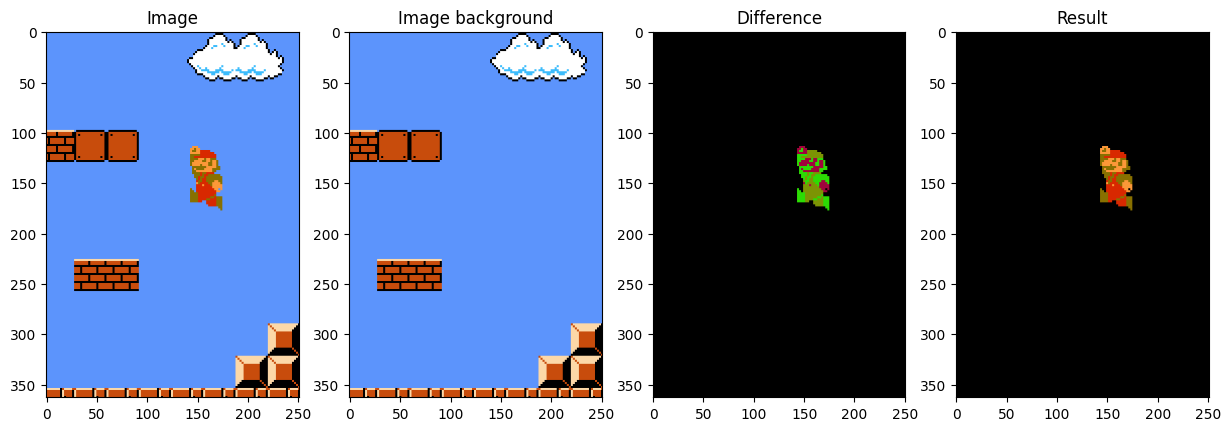

In [102]:
img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_SUB_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# 1) Compute the difference
diff_py = subtraction(img_mario, img_mario_back)

# 2) Create a mask using True/False values 
mask = diff_py!=0

# 3) Create a zero numpy array with the same dimension of the image
res_py = np.zeros_like(img_mario)

# 4) Copy the original pixes from the image to the final result image
res_py[mask] = img_mario[mask]


plt.figure(figsize=(15,15))

plt.subplot(1,4,1)
plt.imshow(img_mario)
plt.title("Image")

plt.subplot(1,4,2)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,4,3)
plt.imshow(diff_py)
plt.title("Difference")

plt.subplot(1,4,4)
plt.imshow(res_py)
plt.title("Result")

In [103]:
# Save the result on device
#res_BGR = cv2.cvtColor(res_py, cv2.COLOR_RGB2BGR)
#cv2.imwrite("./img/mario_jump.jpg", res_BGR)

### OpenCV function

Syntax:
- cv.subtract(src1, src2[, dst[, mask[, dtype]]]	) -> dst

How does it calculate the **substraction with images**:
- dst(I) = saturate( src1(I) - src2(I) )   if mask(I) $\neq$ 0

Parameters: 
- **src1**, **src2**: input images
- **dst**: output images
- **mask**: optional operation mask; this is an 8-bit single channel array that specifies elements of the output array to be changed.
- **dtype**: optional depth of the output array

Example:

In [104]:
img1 = np.array([[10,10], 
                 [20,20]])

img2 = np.array([[20,20],
                 [20,10]])

res = cv2.subtract(img1, img2,dtype=cv2.CV_8U)

print(res)

[[ 0  0]
 [ 0 10]]


In [105]:
IMG_PATH_SUB = "./img/mario-game.png"
IMG_PATH_SUB_BACK = "./img/mario-back.png"

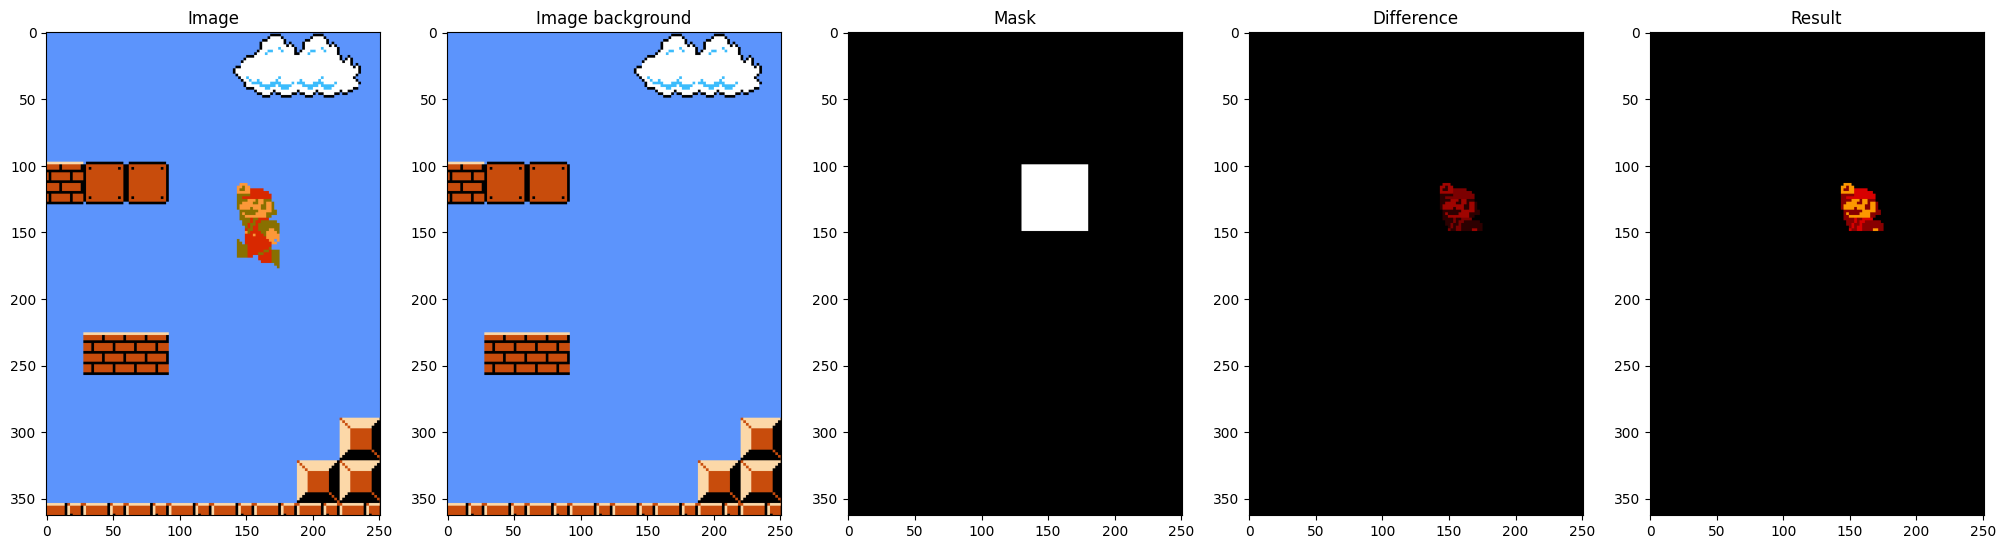

In [106]:
img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_SUB_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# Create the black images for the final result
res = np.zeros_like(img_mario)

# 1) Compute the mask: create a mask using 255/0 values 
h, w = img_mario.shape[:2]
mask_cv = np.zeros((h, w), dtype=np.uint8)
mask_cv[100:150, 130:180] = 255

# 2) Compute difference
diff_cv = cv2.subtract(img_mario, img_mario_back, mask = mask_cv, dtype=cv2.CV_8U)

# 3) Create the mask with True/False values
mask = diff_cv!=0

# 4) #Compute the final result
res_cv = np.zeros_like(img_mario)
res_cv[mask] = img_mario[mask]


plt.figure(figsize=(25,25))

plt.subplot(1,5,1)
plt.imshow(img_mario)
plt.title("Image")


plt.subplot(1,5,2)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,5,3)
plt.imshow(mask_cv, cmap = "gray")
plt.title("Mask")


plt.subplot(1,5,4)
plt.imshow(diff_cv)
plt.title("Difference")

plt.subplot(1,5,5)
plt.imshow(res_cv)
plt.title("Result")

plt.show()


There are some difference between the result of the python function method and the OpenCV method. The overall gaol is achieved but we can study more these differences.

### Comparison between methods

Let's study more deeply the results

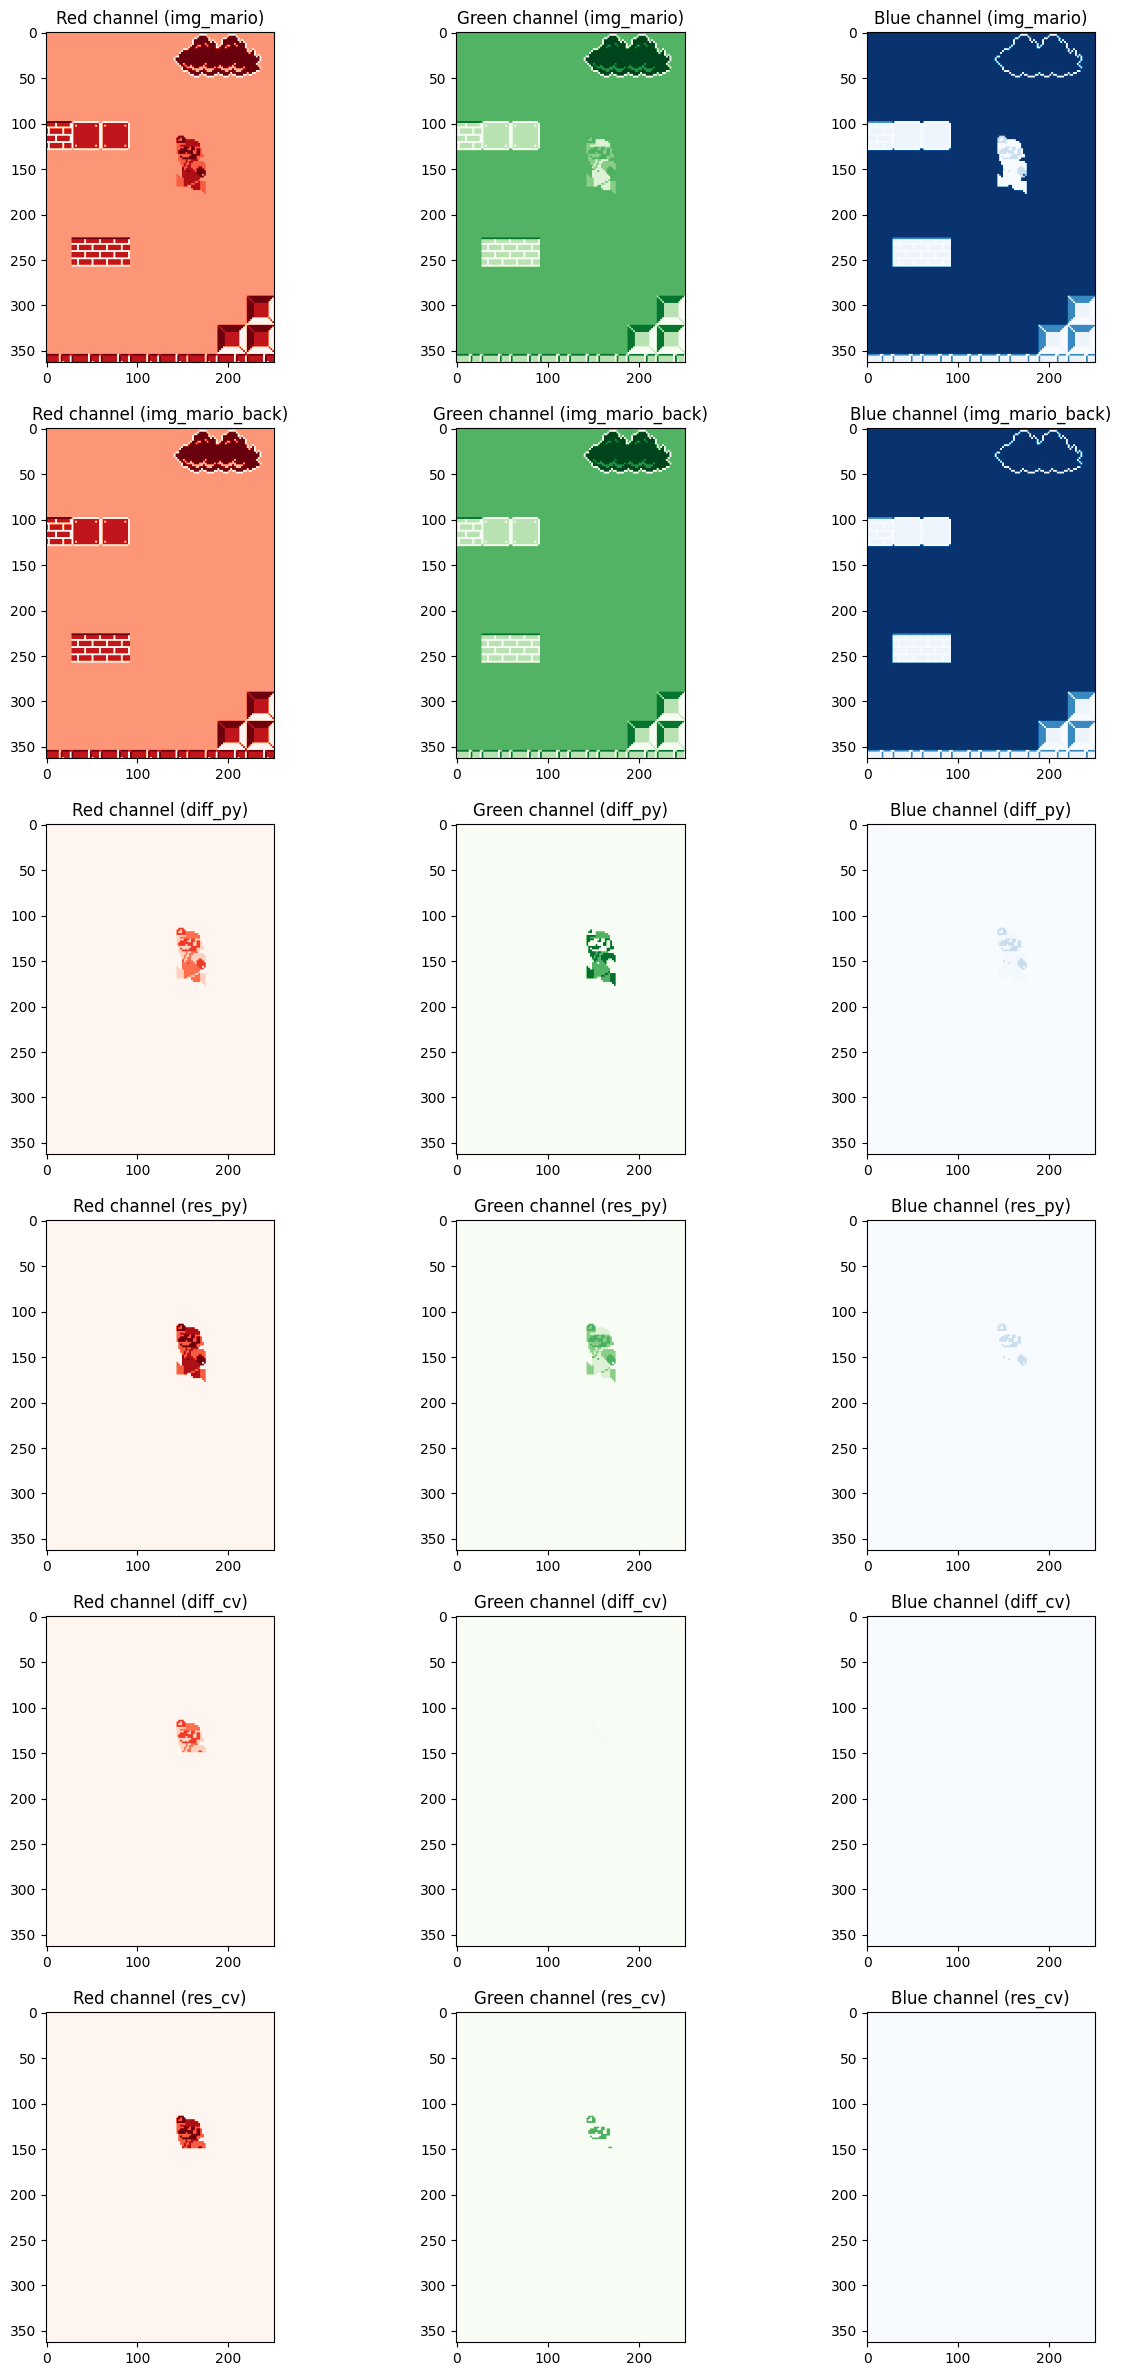

In [107]:
plt.figure(figsize=(15,30))

i = 1

list_img = [
    ("img_mario", img_mario),
    ("img_mario_back", img_mario_back),
    ("diff_py", diff_py),
    ("res_py", res_py),
    ("diff_cv", diff_cv),
    ("res_cv", res_cv)
]

for title, img in list_img:
    r, g, b = cv2.split(img)
    rows = len(list_img)

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(r, cmap="Reds", vmin=0, vmax=255)
    plt.title("Red channel (" + title+ ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(g, cmap="Greens", vmin=0, vmax=255)
    plt.title("Green channel (" + title + ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(b, cmap="Blues", vmin=0, vmax=255)
    plt.title("Blue channel (" + title + ")")





As it can be noticed from the previous plots, the blue channel of the OpenCV method is empty due to the way we perform the calculation.

In [108]:
def get_data(p_x, p_y, channel, img_mario, img_mario_back, diff_py, res_py, diff_cv, res_cv):

    match channel:
        case 0:
            ch_label = "red"
        case 1:
            ch_label = "blue"
        case 2:
            ch_label = "green"

    return (str((p_x, p_y)) + " " + ch_label, img_mario[p_x, p_y , channel], img_mario_back[p_x, p_y, channel], diff_py[p_x, p_y, channel], res_py[p_x, p_y, channel], diff_cv[p_x,p_y, channel], res_cv[p_x, p_y, channel])


In [109]:
data = [
  get_data(135,160,2, img_mario, img_mario_back, diff_py, res_py, diff_cv, res_cv),
  get_data(135,160,1, img_mario, img_mario_back, diff_py, res_py, diff_cv, res_cv),
  get_data(135,160,0, img_mario, img_mario_back, diff_py, res_py, diff_cv, res_cv),
]
table_zoom = PrettyTable(["Example", "img_mario", "img_mario_back", "diff_py", "res_py", "diff_cv", "res_cv"])

for row_label, img_mario_px, img_mario_back_px, diff_py_px, res_py_px, diff_cv_px, res_cv_px in data:
  table_zoom.add_row([row_label, img_mario_px, img_mario_back_px, diff_py_px, res_py_px, diff_cv_px, res_cv_px])

print(table_zoom)


+------------------+-----------+----------------+---------+--------+---------+--------+
|     Example      | img_mario | img_mario_back | diff_py | res_py | diff_cv | res_cv |
+------------------+-----------+----------------+---------+--------+---------+--------+
| (135, 160) green |     56    |      252       |    60   |   56   |    0    |   0    |
| (135, 160) blue  |    152    |      148       |    4    |  152   |    4    |  152   |
|  (135, 160) red  |    252    |       92       |   160   |  252   |   160   |  252   |
+------------------+-----------+----------------+---------+--------+---------+--------+


### Conclusion

As I have written before, there isn't an absoulte better solution. Depends on the taks. In these experiments, the goal is to remove the background and just focus on mario character. In this case it's preferable to use the second version of the python function because when pixel1 - pixel2 is performed and the result is negative, the wrap around mechanism assigns a values $\neq$ 0. In this way, when I use the result as a mask to get the original pixel value of mario, then those pixels (that should be theoretically negative) will have a positive value (so in the mask are considered as a True value) and the original pixel will be retrieved. Otherwise if I clip the values between 0 and 255 (like in np.subtract), all the negative numbers will be substitute with zero and when I will use those pixels in the mask, they will not let me retrieve the origianl pixel of mario. This effect doesn't happen strongly in these examples that I have shown and it is not visible to the human eye but theoretically some pixels could miss in the final result (this phenomenon can be seen very well in the chapter 'Comparison between methods')

## Addition

There are several way to perform addition

### Python function

We have wrap around also for addition

In [110]:
val1 = np.array([200], dtype = np.uint8)
val2 = np.array([200], dtype = np.uint8)

print (val1 + val2)

[144]


The considerations and comments that I have made for the subtraction are similar for addition. We can define several ways to code the addition in Python

In [111]:
# First version
def addition(img1, img2):
    
    # Check the type of array (in this case, I'd like to work with uint8)
    assert img1.dtype == np.uint8 
    assert img2.dtype == np.uint8 

    return img1 + img2

# Second version
"""
def addition(img1, img2):
    return np.clip(img1 + img2, 0, 255)
"""

# Third version
"""
def addition(img1, img2):
    sum = img1.astype(np.uint16) - img2.astype(np.uint16)
    return np.clip(sum, 0, 255).astype(np.uint8)
"""

'\ndef addition(img1, img2):\n    sum = img1.astype(np.uint16) - img2.astype(np.uint16)\n    return np.clip(sum, 0, 255).astype(np.uint8)\n'

In [112]:
IMG_PATH_ADD = "./img/mario_jump.jpg"
IMG_PATH_ADD_BACK  = "./img/mario-back.png"

Text(0.5, 1.0, 'Sum result')

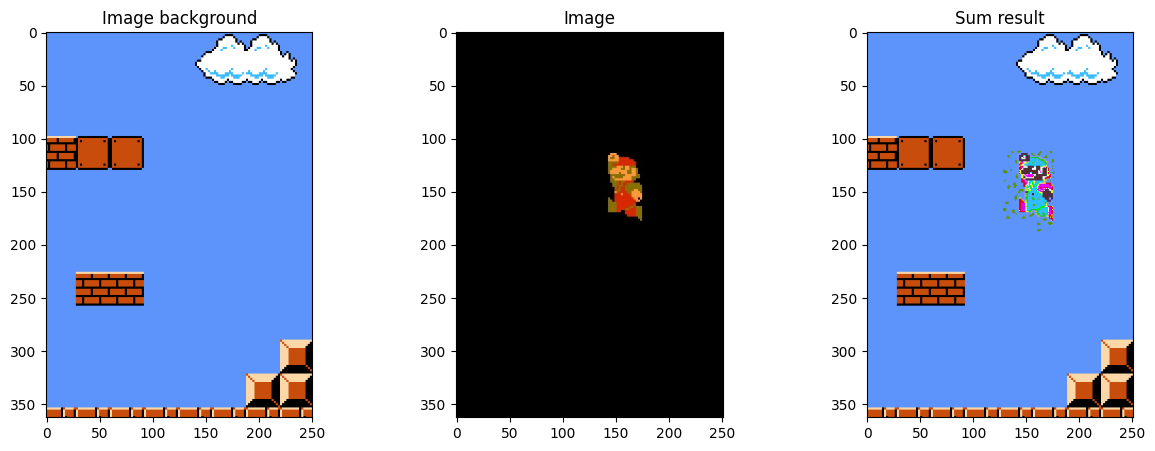

In [113]:
img_mario = cv2.imread(IMG_PATH_ADD)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_ADD_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# 1) Compute the addition
add_py = addition(img_mario_back, img_mario)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,3,2)
plt.imshow(img_mario)
plt.title("Image")

plt.subplot(1,3,3)
plt.imshow(add_py)
plt.title("Sum result")

Due to the wrap around effect, the final result has colours that are different from the orinal mario image. The pixels are not saturated but the colours aren't the same

### OpenCV function

Syntax:
- cv.add(src1, src2[, dst[, mask[, dtype]]]	) -> dst

How does it calculate the **substraction with images**:
- dst(I) = saturate( src1(I) + src2(I) )   if mask(I) $\neq$ 0

Parameters: 
- **src1**, **src2**: input images
- **dst**: output images
- **mask**: optional operation mask; this is an 8-bit single channel array that specifies elements of the output array to be changed.
- **dtype**: optional depth of the output array

In [114]:
img1 = np.array([[120,10], 
                 [20,20]])

img2 = np.array([[200,20],
                 [20,10]])

res = cv2.add(img1, img2, dtype=cv2.CV_8U)

print(res, res.dtype)

[[255  30]
 [ 40  30]] uint8


Text(0.5, 1.0, 'Sum result')

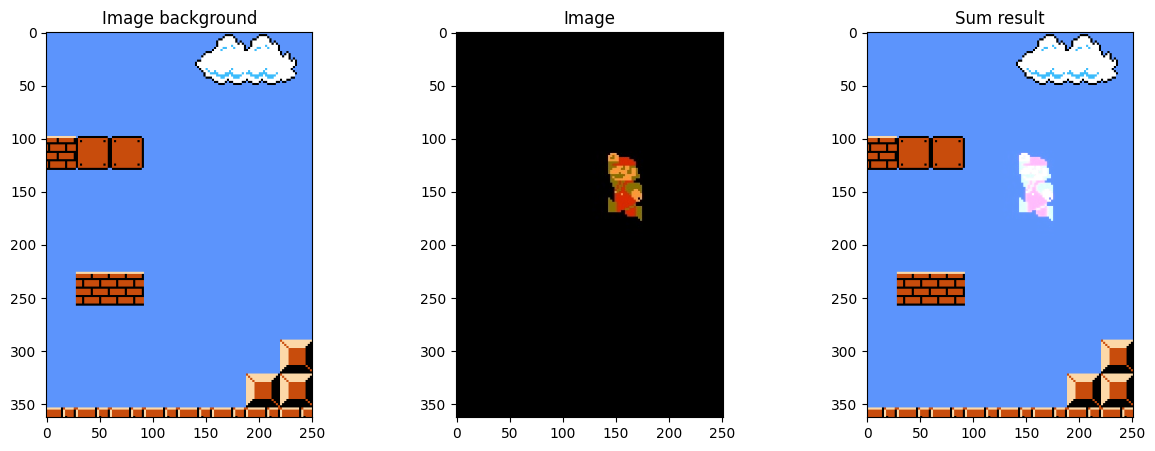

In [115]:
img_mario = cv2.imread(IMG_PATH_ADD)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_ADD_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# 1) Compute the addition
add_cv = cv2.add(img_mario_back, img_mario, dtype=cv2.CV_8U)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,3,2)
plt.imshow(img_mario)
plt.title("Image")

plt.subplot(1,3,3)
plt.imshow(add_cv)
plt.title("Sum result")

As we can notice, a lot of pixels are saturated because OpenCV doesn't wrap around (200 + 200 = 255 -> no wrap around)

### Comparison between methods

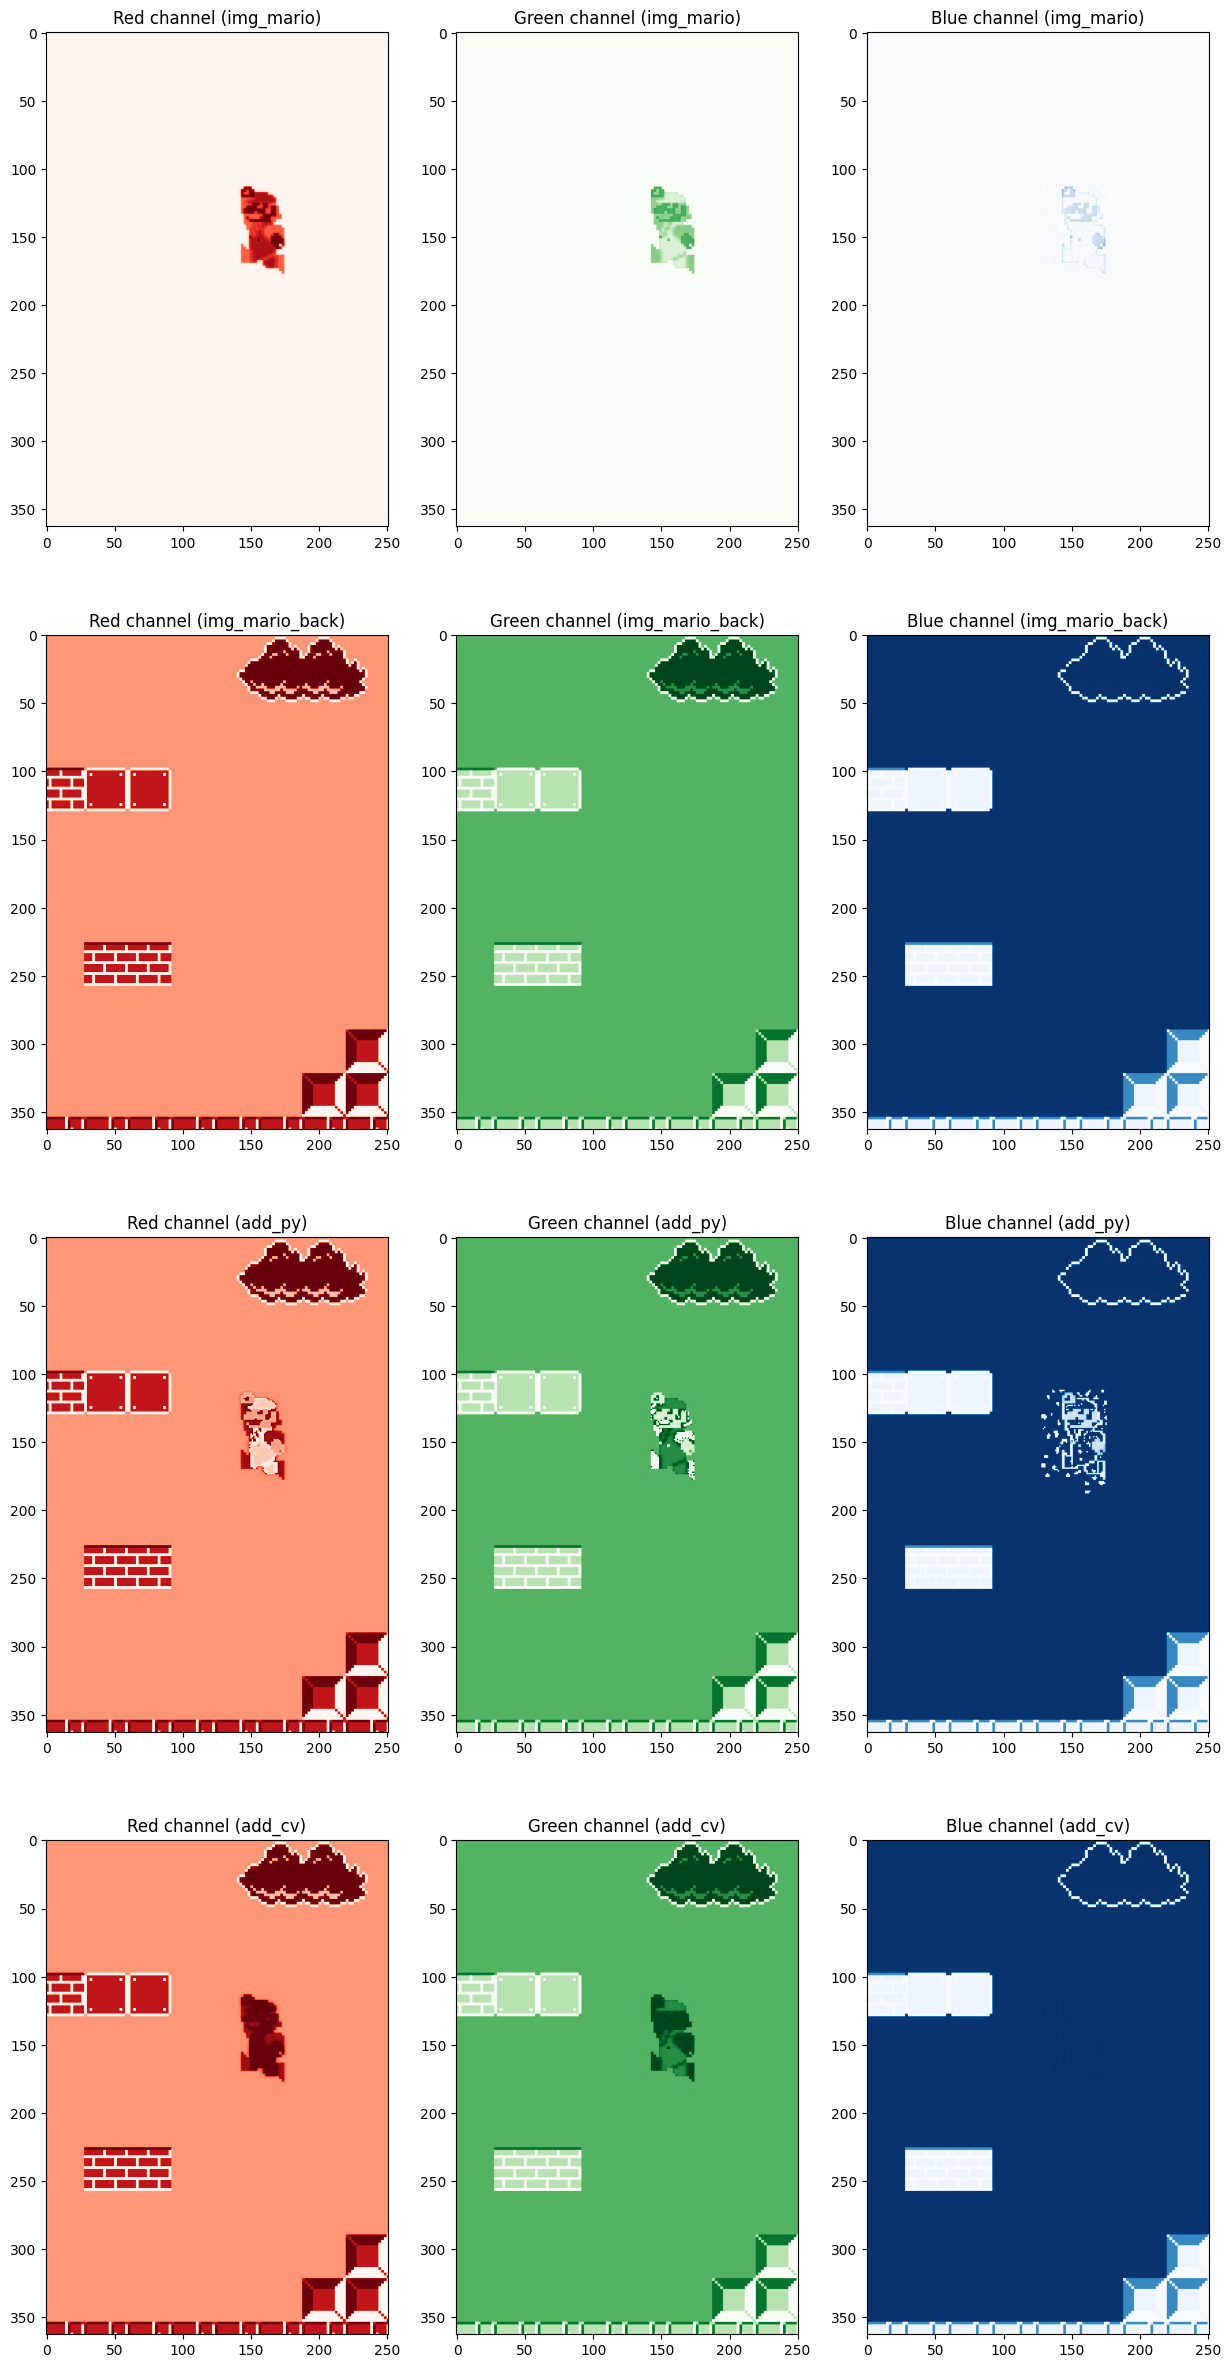

In [116]:
plt.figure(figsize=(15,30))

i = 1

list_img = [
    ("img_mario", img_mario),
    ("img_mario_back", img_mario_back),
    ("add_py", add_py),
    ("add_cv", add_cv)
]

for title, img in list_img:
    r, g, b = cv2.split(img)
    rows = len(list_img)

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(r, cmap="Reds", vmin=0, vmax=255)
    plt.title("Red channel (" + title+ ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(g, cmap="Greens", vmin=0, vmax=255)
    plt.title("Green channel (" + title + ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(b, cmap="Blues", vmin=0, vmax=255)
    plt.title("Blue channel (" + title + ")")





We can notice that in add_cv most of the pixels (that are involved for the sum) are saturated. In contrast, in add_py the pixels are more visible due to the wrap around effect (so most of the pixels are not saturated)

In [117]:
def get_data(p_x, p_y, channel, img_mario, img_mario_back,  add_py, add_cv):

    match channel:
        case 0:
            ch_label = "red"
        case 1:
            ch_label = "blue"
        case 2:
            ch_label = "green"

    return (str((p_x, p_y)) + " " + ch_label, img_mario[p_x, p_y , channel], img_mario_back[p_x, p_y, channel], add_py[p_x, p_y, channel], add_cv[p_x, p_y, channel])


In [118]:
data = [
  get_data(135,160,2, img_mario, img_mario_back, add_py, add_cv),
  get_data(135,160,1, img_mario, img_mario_back, add_py, add_cv),
  get_data(135,160,0, img_mario, img_mario_back, add_py, add_cv),

  get_data(160,160,2, img_mario, img_mario_back, add_py, add_cv),
  get_data(160,160,1, img_mario, img_mario_back, add_py, add_cv),
  get_data(160,160,0, img_mario, img_mario_back, add_py, add_cv),
]
table_zoom = PrettyTable(["Example", "img_mario", "img_mario_back", "add_py", "add_cv"])

for row_label, img_mario_px, img_mario_back_px, add_py_px, add_cv_px in data:
  table_zoom.add_row([row_label, img_mario_px, img_mario_back_px, add_py_px, add_cv_px ])

print(table_zoom)

+------------------+-----------+----------------+--------+--------+
|     Example      | img_mario | img_mario_back | add_py | add_cv |
+------------------+-----------+----------------+--------+--------+
| (135, 160) green |     57    |      252       |   53   |  255   |
| (135, 160) blue  |    153    |      148       |   45   |  255   |
|  (135, 160) red  |    246    |       92       |   82   |  255   |
| (160, 160) green |     0     |      252       |  252   |  252   |
| (160, 160) blue  |     40    |      148       |  188   |  188   |
|  (160, 160) red  |    215    |       92       |   51   |  255   |
+------------------+-----------+----------------+--------+--------+


The table shows exactly the results of the different way to sum 2 pixels (add_py and add_cv)

### Conclusion

Also for this chapter (addition), there isn't an absolute better method but it depends on the application. We have seen different functions that make the same thing (add pixels) but the result is different based on the technique involved.

## Alpha blending

Alpha blending is the process of overlaying a foreground image on a background image. The general formula is:
$$g(x) = (1 - \alpha)f_0(x) +  \alpha f_1(x)$$

### Python function

In [119]:
def alpha_bleding(img1, img2, alpha, x, y):
    h, w = img2.shape[:2]
    a = alpha / 255 # Convert alpha channel from [0,255] to [0,1]
    res = img1.copy()
    res[y:y+h,x:x+w] = img1[y:y+h,x:x+w]*(1.0-a) + img2*a
    return res

In [120]:
IMG_PATH_BACK = "./img/hill.jpg"
IMG_PATH = "./img/study.png"
IMG_ALPHA = "./img/study-alpha.png"

Text(0.5, 1.0, 'Result')

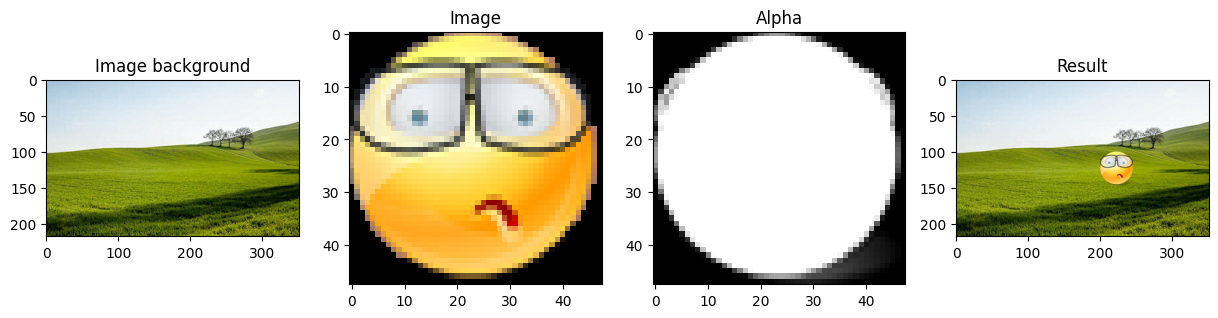

In [121]:
img1 = cv2.imread(IMG_PATH_BACK)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(IMG_PATH)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

alpha = cv2.imread(IMG_ALPHA)
alpha = cv2.cvtColor(alpha, cv2.COLOR_BGR2RGB)

res = alpha_bleding(img1, img2, alpha, 200, 100)

plt.figure(figsize=(15,15))

plt.subplot(1,4,1)
plt.imshow(img1)
plt.title("Image background")

plt.subplot(1,4,2)
plt.imshow(img2)
plt.title("Image")

plt.subplot(1,4,3)
plt.imshow(alpha)
plt.title("Alpha")

plt.subplot(1,4,4)
plt.imshow(res)
plt.title("Result")


### OpenCV function

The function addWeighted calculates the weighted sum of two arrays as follows:

$$dst(I)=saturate(src1(I)∗alpha+src2(I)∗beta+gamma)$$


Syntax:
- cv2.addWeighted(	src1, alpha, src2, beta, gamma[, dst[, dtype]]	) -> dst

Parameters:
- src1: first input array.
- alpha: weight of the first array elements.
- src2: second input array of the same size and channel number as src1.
- beta:	weight of the second array elements.
- gamma: scalar added to each sum.
- dst: output array that has the same size and number of channels as the input arrays.
- dtype: optional depth of the output array; when both input arrays have the same depth, dtype can be set to -1 which will be equivalent to src1.depth().


In [122]:
IMG_PATH_BACK = "./img/hill.jpg"
IMG_PATH = "./img/study.png"
IMG_ALPHA = "./img/study-alpha.png"

Text(0.5, 1.0, 'Result')

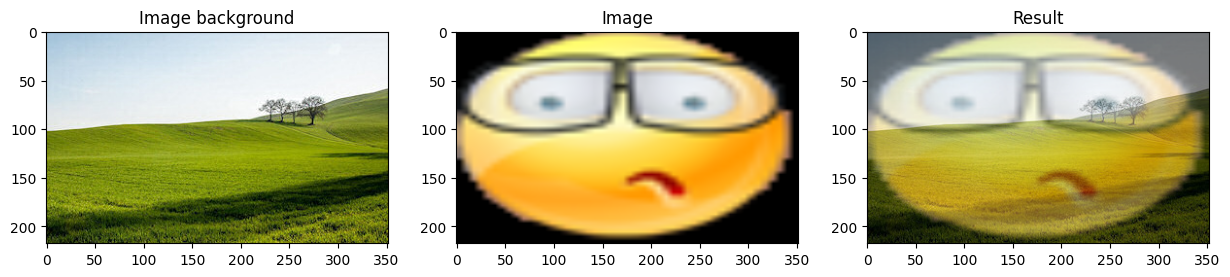

In [123]:
img1 = cv2.imread(IMG_PATH_BACK)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(IMG_PATH)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2 = cv2.resize(img2, img1.shape[1::-1])

alpha = 0.5
beta = 1.0 - alpha
res = cv2.addWeighted(img1, alpha, img2, beta, 0.0)

plt.figure(figsize=(15,15))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title("Image background")

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title("Image")


plt.subplot(1,3,3)
plt.imshow(res)
plt.title("Result")


## Bitwise operation